# Perbandingan Skenario SRL-NER: E1 vs S1 vs S2

Notebook ini membandingkan tiga skenario eksperimen self-training BERT:

- **E1 (Baseline)** — threshold 0.9 fix, tanpa class weight
- **S1 (Class Weight)** — threshold 0.9 fix + balanced class weight
- **S2 (Adaptive + Class Weight)** — threshold turun 0.9→0.7 adaptif + class weight

Hasil dianalisis dari tiga perspektif metrik (token-weighted, macro tanpa O, seqeval entity-level) untuk menunjukkan trade-off precision–recall.

**Sumber data:** `done_running/{baseline,S1_classweight,S2_adaptive}/output/evaluation/`

**Dependency:** `pip install seqeval matplotlib seaborn` (selain pandas/sklearn yang sudah ada).

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.metrics import (precision_recall_fscore_support, classification_report,
                             confusion_matrix)

try:
    from seqeval.metrics import (classification_report as seq_cr,
                                 f1_score as seq_f1,
                                 precision_score as seq_p,
                                 recall_score as seq_r)
    HAS_SEQEVAL = True
except ImportError:
    HAS_SEQEVAL = False
    print('[warn] seqeval not installed -> entity-level metrics akan dilewati')
    print('       Jalankan:  pip install seqeval')

BASE = os.path.dirname(os.path.abspath('.')) if False else '.'
# Resolve relative ke notebook (asumsi notebook dijalankan di done_running/)
ROOT = '.'

FILES = {
    'E1': {
        'iter_log':   f'{ROOT}/baseline/output/evaluation/iteration_log.csv',
        'correct':    f'{ROOT}/baseline/output/evaluation/bert-only-sirah-ner-iterative-6-correct.xlsx',
        'incorrect':  f'{ROOT}/baseline/output/evaluation/bert-only-sirah-ner-iterative-6-incorrect.xlsx',
        'misclass':   f'{ROOT}/baseline/output/evaluation/bert-only-sirah-ner-confidence-0.9-misclassified.xlsx',
    },
    'S1': {
        'iter_log':   f'{ROOT}/S1_classweight/output/evaluation/iteration_log_bert-only-sirah-ner-S1.csv',
        'correct':    f'{ROOT}/S1_classweight/output/evaluation/bert-only-sirah-ner-S1-iterative-6-correct.xlsx',
        'incorrect':  f'{ROOT}/S1_classweight/output/evaluation/bert-only-sirah-ner-S1-iterative-6-incorrect.xlsx',
        'misclass':   f'{ROOT}/S1_classweight/output/evaluation/bert-only-sirah-ner-S1-confidence-0.9-misclassified.xlsx',
    },
    'S2': {
        'iter_log':   f'{ROOT}/S2_adaptive/output/evaluation/iteration_log_bert-only-sirah-ner-S2.csv',
        'correct':    f'{ROOT}/S2_adaptive/output/evaluation/bert-only-sirah-ner-S2-iterative-2-correct.xlsx',
        'incorrect':  f'{ROOT}/S2_adaptive/output/evaluation/bert-only-sirah-ner-S2-iterative-2-incorrect.xlsx',
        'misclass':   f'{ROOT}/S2_adaptive/output/evaluation/bert-only-sirah-ner-S2-iter2-misclassified.xlsx',
    },
}

SCENARIO_COLOR = {'E1': '#1f77b4', 'S1': '#ff7f0e', 'S2': '#2ca02c'}

for scen, paths in FILES.items():
    for kind, p in paths.items():
        ok = os.path.exists(p)
        print(f'{scen:>3} {kind:<10} {"OK" if ok else "MISSING"}  {p}')

 E1 iter_log   OK  ./baseline/output/evaluation/iteration_log.csv
 E1 correct    OK  ./baseline/output/evaluation/bert-only-sirah-ner-iterative-6-correct.xlsx
 E1 incorrect  OK  ./baseline/output/evaluation/bert-only-sirah-ner-iterative-6-incorrect.xlsx
 E1 misclass   OK  ./baseline/output/evaluation/bert-only-sirah-ner-confidence-0.9-misclassified.xlsx
 S1 iter_log   OK  ./S1_classweight/output/evaluation/iteration_log_bert-only-sirah-ner-S1.csv
 S1 correct    OK  ./S1_classweight/output/evaluation/bert-only-sirah-ner-S1-iterative-6-correct.xlsx
 S1 incorrect  OK  ./S1_classweight/output/evaluation/bert-only-sirah-ner-S1-iterative-6-incorrect.xlsx
 S1 misclass   OK  ./S1_classweight/output/evaluation/bert-only-sirah-ner-S1-confidence-0.9-misclassified.xlsx
 S2 iter_log   OK  ./S2_adaptive/output/evaluation/iteration_log_bert-only-sirah-ner-S2.csv
 S2 correct    OK  ./S2_adaptive/output/evaluation/bert-only-sirah-ner-S2-iterative-2-correct.xlsx
 S2 incorrect  OK  ./S2_adaptive/output/e

## 1. Dinamika Pseudo-Labelling per Iterasi

Plot jumlah pseudo-label yang lolos threshold per iterasi, untuk lihat laju konvergensi self-training tiap skenario.

In [2]:
iter_logs = {scen: pd.read_csv(FILES[scen]['iter_log']) for scen in ['E1','S1','S2']}

for scen, df in iter_logs.items():
    print(f'\n[{scen}] iteration log:')
    print(df.to_string(index=False))

summary = []
for scen, df in iter_logs.items():
    summary.append({
        'Skenario': scen,
        'Total iter': len(df),
        'Total pseudo-label': int(df['n_above'].sum()),
        'Iter 1': int(df['n_above'].iloc[0]),
    })
summary_df = pd.DataFrame(summary)
print('\n=== Ringkasan ===')
print(summary_df.to_string(index=False))


[E1] iteration log:
 iter  n_above
    1      187
    2       32
    3       14
    4        2
    5        1
    6        1

[S1] iteration log:
 iter  n_above
    1      185
    2       31
    3       15
    4        5
    5        1

[S2] iteration log:
 iter  threshold_used  n_above
    1             0.9      197
    2             0.7       40

=== Ringkasan ===
Skenario  Total iter  Total pseudo-label  Iter 1
      E1           6                 237     187
      S1           5                 237     185
      S2           2                 237     197


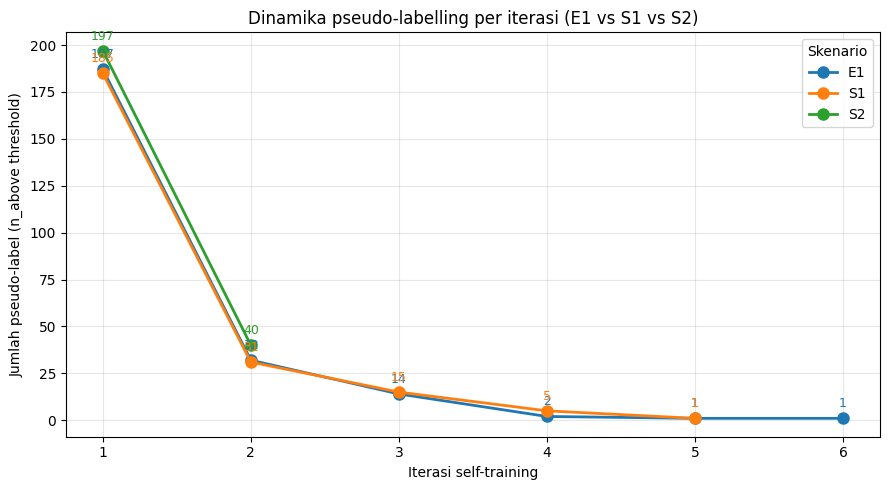

Saved: fig_pseudo_per_iter.png


In [3]:
fig, ax = plt.subplots(figsize=(9,5))
for scen, df in iter_logs.items():
    ax.plot(df['iter'], df['n_above'], 'o-', label=scen,
            color=SCENARIO_COLOR[scen], linewidth=2, markersize=8)
    for _, row in df.iterrows():
        ax.annotate(int(row['n_above']),
                    xy=(row['iter'], row['n_above']),
                    xytext=(0,8), textcoords='offset points',
                    ha='center', fontsize=9, color=SCENARIO_COLOR[scen])

ax.set_xlabel('Iterasi self-training')
ax.set_ylabel('Jumlah pseudo-label (n_above threshold)')
ax.set_title('Dinamika pseudo-labelling per iterasi (E1 vs S1 vs S2)')
ax.legend(title='Skenario', loc='upper right')
ax.grid(alpha=0.3)
ax.set_xticks(range(1, 7))
plt.tight_layout()
plt.savefig(f'{ROOT}/fig_pseudo_per_iter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_pseudo_per_iter.png')

## 2. Load Hasil Test Set per Skenario

In [4]:
def load_test_results(scen):
    c = pd.read_excel(FILES[scen]['correct'])
    i = pd.read_excel(FILES[scen]['incorrect'])
    df = pd.concat([c, i], ignore_index=True)
    return df

test_dfs = {scen: load_test_results(scen) for scen in ['E1','S1','S2']}
for scen, df in test_dfs.items():
    correct = (df['true_label'] == df['pred_label']).sum()
    print(f'{scen}: total token = {len(df):>6}  correct = {correct:>6}  acc = {correct/len(df):.4f}')

E1: total token =  42558  correct =  42363  acc = 0.9954
S1: total token =  42558  correct =  42125  acc = 0.9898
S2: total token =  42558  correct =  41767  acc = 0.9814


## 3. Metric A — Token-level Weighted F1 (termasuk O)

⚠️ **Misleading karena 93% token = "O".** Sebagian besar bobot ada di majority class.

In [5]:
rows = []
for scen, df in test_dfs.items():
    p, r, f, _ = precision_recall_fscore_support(
        df['true_label'], df['pred_label'], average='weighted', zero_division=0)
    acc = (df['true_label'] == df['pred_label']).mean()
    rows.append({'Skenario': scen, 'Accuracy': acc, 'Precision': p, 'Recall': r, 'F1 (weighted)': f})

token_df = pd.DataFrame(rows).round(4)
print(token_df.to_string(index=False))

Skenario  Accuracy  Precision  Recall  F1 (weighted)
      E1    0.9954     0.9955  0.9954         0.9955
      S1    0.9898     0.9910  0.9898         0.9902
      S2    0.9814     0.9855  0.9814         0.9826


## 4. Metric B — Macro F1 Tanpa "O" (fair untuk unbalanced)

In [6]:
rows = []
for scen, df in test_dfs.items():
    mask = df['true_label'] != 'O'
    yt = df.loc[mask, 'true_label']; yp = df.loc[mask, 'pred_label']
    p, r, f, _ = precision_recall_fscore_support(yt, yp, average='macro', zero_division=0)
    rows.append({'Skenario': scen, 'Precision (macro)': p, 'Recall (macro)': r,
                 'F1 (macro)': f, 'N entity tokens': len(yt)})

macro_df = pd.DataFrame(rows).round(4)
print(macro_df.to_string(index=False))

Skenario  Precision (macro)  Recall (macro)  F1 (macro)  N entity tokens
      E1             0.8673          0.8270      0.8463             3109
      S1             0.8720          0.8493      0.8601             3109
      S2             0.8732          0.8534      0.8627             3109


## 5. Metric C — Seqeval Entity-Level F1 (span-based, standar NER)

Mengukur apakah **span entitas penuh** (B + I tokens) tepat. Ini adalah metrik standar di literatur NER (CoNLL-2003).

In [7]:
def to_seqeval_format(df):
    """Group by text_id -> sequences, convert B_X to B-X for seqeval."""
    true_seqs, pred_seqs = [], []
    for _, grp in df.groupby('text_id', sort=False):
        tl = [x.replace('_','-',1) if x.startswith(('B_','I_')) else x for x in grp['true_label']]
        pl = [x.replace('_','-',1) if x.startswith(('B_','I_')) else x for x in grp['pred_label']]
        true_seqs.append(tl); pred_seqs.append(pl)
    return true_seqs, pred_seqs

if HAS_SEQEVAL:
    rows = []
    per_entity_data = {}
    for scen, df in test_dfs.items():
        true_seqs, pred_seqs = to_seqeval_format(df)
        p = seq_p(true_seqs, pred_seqs)
        r = seq_r(true_seqs, pred_seqs)
        f = seq_f1(true_seqs, pred_seqs)
        rows.append({'Skenario': scen, 'Precision (entity)': p, 'Recall (entity)': r, 'F1 (entity)': f})
        rep = seq_cr(true_seqs, pred_seqs, output_dict=True, zero_division=0)
        per_entity_data[scen] = {k: v for k, v in rep.items()
                                  if k not in ('micro avg','macro avg','weighted avg')}
    seqeval_df = pd.DataFrame(rows).round(4)
    print(seqeval_df.to_string(index=False))
else:
    seqeval_df = pd.DataFrame()
    per_entity_data = {}
    print('seqeval tidak terinstall. pip install seqeval')

Skenario  Precision (entity)  Recall (entity)  F1 (entity)
      E1              0.9542           0.9633       0.9587
      S1              0.8517           0.9723       0.9080
      S2              0.7404           0.9791       0.8432


## 6. Per-Entity F1 Breakdown

Yang paling penting untuk argumen revisi Bu Diana: **kelas EVENT (paling minoritas) seharusnya membaik dengan class weight**.

In [8]:
if HAS_SEQEVAL:
    entities = ['PERSON', 'LOCATION', 'TIME', 'EVENT']
    rows = []
    for ent in entities:
        row = {'Entity': ent}
        for scen in ['E1','S1','S2']:
            if ent in per_entity_data[scen]:
                row[f'F1_{scen}'] = round(per_entity_data[scen][ent]['f1-score'], 3)
                row[f'R_{scen}'] = round(per_entity_data[scen][ent]['recall'], 3)
                row[f'P_{scen}'] = round(per_entity_data[scen][ent]['precision'], 3)
        if 'PERSON' in per_entity_data['E1']:
            row['Support'] = int(per_entity_data['E1'].get(ent, {}).get('support', 0))
        rows.append(row)
    per_ent_df = pd.DataFrame(rows)
    print('\nF1 per-entity:')
    print(per_ent_df[['Entity','Support','F1_E1','F1_S1','F1_S2']].to_string(index=False))
    print('\nRecall per-entity:')
    print(per_ent_df[['Entity','Support','R_E1','R_S1','R_S2']].to_string(index=False))
    print('\nPrecision per-entity:')
    print(per_ent_df[['Entity','Support','P_E1','P_S1','P_S2']].to_string(index=False))


F1 per-entity:
  Entity  Support  F1_E1  F1_S1  F1_S2
  PERSON     1196  0.972  0.919  0.851
LOCATION      450  0.954  0.912  0.850
    TIME       76  0.883  0.780  0.712
   EVENT       51  0.816  0.835  0.830

Recall per-entity:
  Entity  Support  R_E1  R_S1  R_S2
  PERSON     1196 0.977 0.982 0.991
LOCATION      450 0.944 0.971 0.969
    TIME       76 0.947 0.934 0.961
   EVENT       51 0.824 0.827 0.830

Precision per-entity:
  Entity  Support  P_E1  P_S1  P_S2
  PERSON     1196 0.966 0.863 0.745
LOCATION      450 0.964 0.860 0.758
    TIME       76 0.828 0.670 0.566
   EVENT       51 0.808 0.843 0.830


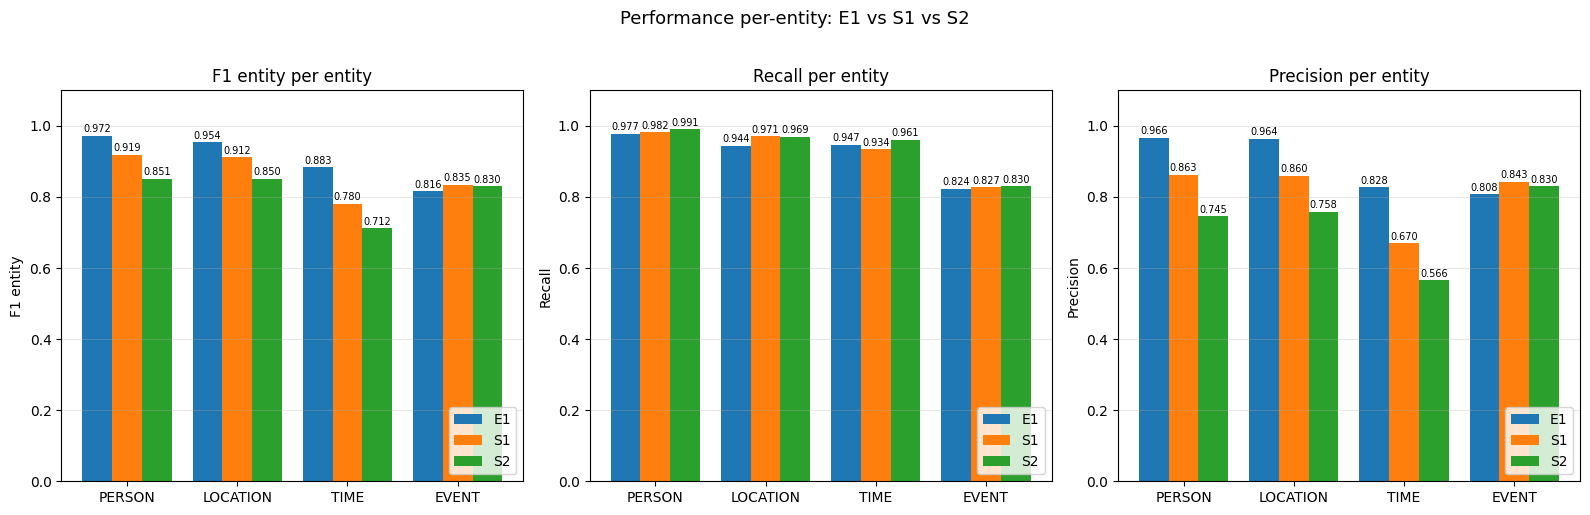

Saved: fig_per_entity.png


In [9]:
if HAS_SEQEVAL:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    metric_names = [('F1', 'F1 entity'), ('R', 'Recall'), ('P', 'Precision')]

    for ax, (key, title) in zip(axes, metric_names):
        x = np.arange(len(entities))
        width = 0.27
        for j, scen in enumerate(['E1','S1','S2']):
            vals = [per_entity_data[scen][e][f'{"f1-score" if key=="F1" else "recall" if key=="R" else "precision"}'] for e in entities]
            ax.bar(x + (j-1)*width, vals, width, label=scen, color=SCENARIO_COLOR[scen])
            for xi, v in zip(x + (j-1)*width, vals):
                ax.text(xi, v + 0.01, f'{v:.3f}', ha='center', fontsize=7)
        ax.set_xticks(x); ax.set_xticklabels(entities)
        ax.set_ylim(0, 1.1)
        ax.set_ylabel(title); ax.set_title(f'{title} per entity')
        ax.legend(loc='lower right')
        ax.grid(axis='y', alpha=0.3)
    plt.suptitle('Performance per-entity: E1 vs S1 vs S2', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(f'{ROOT}/fig_per_entity.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: fig_per_entity.png')

## 7. Confusion Matrix Side-by-side

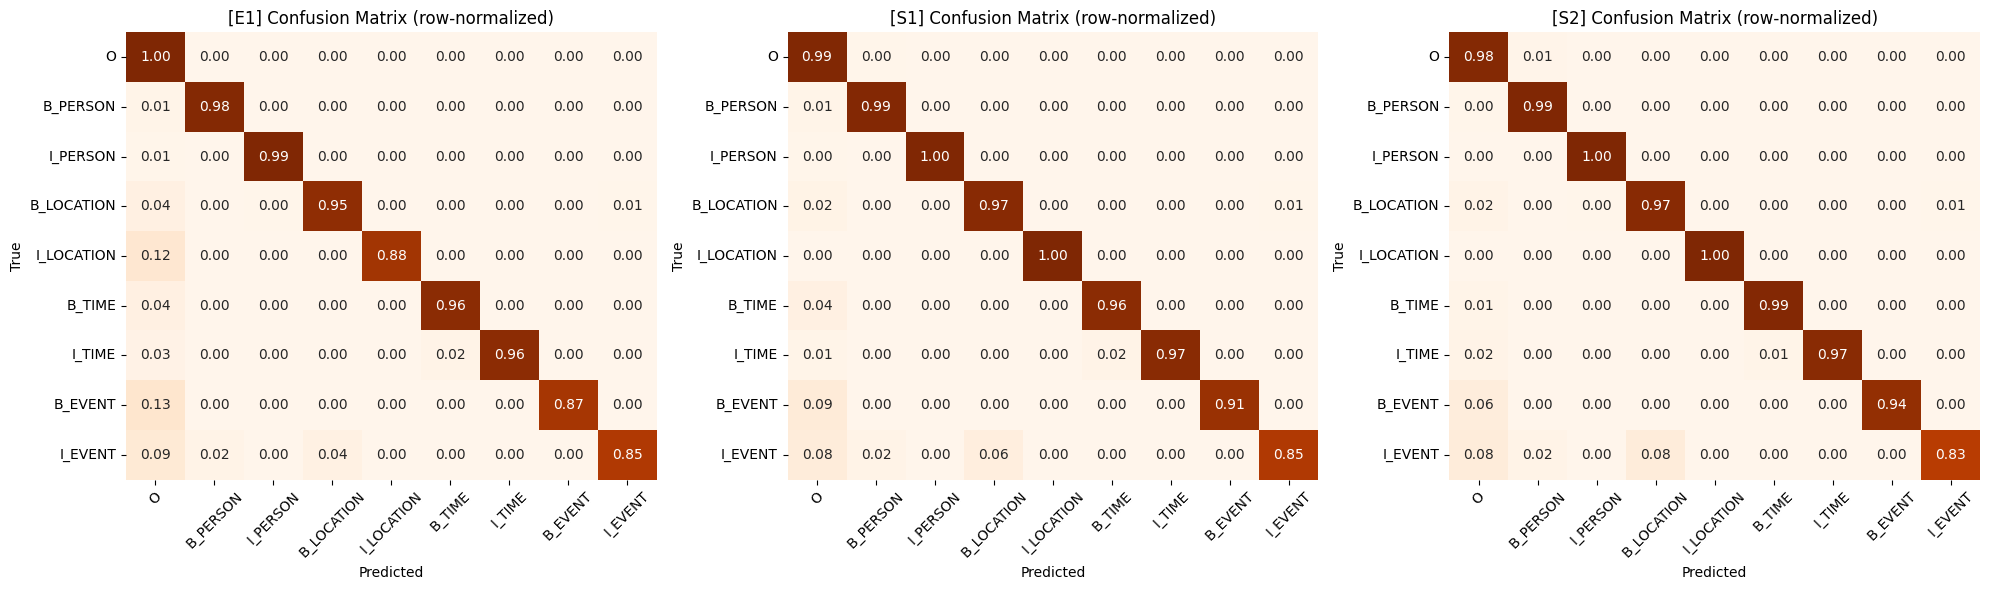

Saved: fig_confusion.png


In [10]:
labels_order = ['O','B_PERSON','I_PERSON','B_LOCATION','I_LOCATION','B_TIME','I_TIME','B_EVENT','I_EVENT']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, scen in zip(axes, ['E1','S1','S2']):
    df = test_dfs[scen]
    cm = confusion_matrix(df['true_label'], df['pred_label'], labels=labels_order)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Oranges', ax=ax,
                xticklabels=labels_order, yticklabels=labels_order, cbar=False, vmin=0, vmax=1)
    ax.set_title(f'[{scen}] Confusion Matrix (row-normalized)')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(f'{ROOT}/fig_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_confusion.png')

## 8. Pola Error — Top-10 Misclassifications

In [11]:
for scen in ['E1','S1','S2']:
    df_mis = pd.read_excel(FILES[scen]['misclass'])
    pairs = list(zip(df_mis['true_label'], df_mis['pred_label']))
    cnt = Counter(pairs).most_common(10)
    total = len(df_mis)
    print(f'\n=== [{scen}] total errors = {total} ===')
    print(f'  {"true":>14} -> {"pred":<14}  {"n":>4}    %')
    for (t, p), n in cnt:
        print(f'  {t:>14} -> {p:<14}  {n:>4}  {100*n/total:>5.1f}%')


=== [E1] total errors = 195 ===
            true -> pred               n    %
               O -> B_PERSON          33   16.9%
               O -> I_PERSON          28   14.4%
               O -> I_TIME            20   10.3%
      B_LOCATION -> O                 18    9.2%
        B_PERSON -> O                 17    8.7%
               O -> B_LOCATION        11    5.6%
               O -> B_EVENT            7    3.6%
               O -> B_TIME             6    3.1%
        I_PERSON -> O                  6    3.1%
               O -> I_LOCATION         6    3.1%

=== [S1] total errors = 433 ===
            true -> pred               n    %
               O -> B_PERSON         170   39.3%
               O -> B_LOCATION        65   15.0%
               O -> I_PERSON          54   12.5%
               O -> I_TIME            38    8.8%
               O -> B_TIME            26    6.0%
        B_PERSON -> O                 14    3.2%
               O -> I_LOCATION        14    3.2%
      B_L

## 9. Tabel Ringkasan Final

Satu tabel rangkum semua metrik untuk dimasukkan langsung ke laporan.

In [12]:
summary_rows = []
for scen in ['E1','S1','S2']:
    df = test_dfs[scen]
    log = iter_logs[scen]
    df_mis = pd.read_excel(FILES[scen]['misclass'])
    row = {'Skenario': scen}
    p, r, f, _ = precision_recall_fscore_support(df['true_label'], df['pred_label'], average='weighted', zero_division=0)
    row['F1 token-weighted'] = round(f, 4)
    mask = df['true_label'] != 'O'
    p2, r2, f2, _ = precision_recall_fscore_support(df.loc[mask,'true_label'], df.loc[mask,'pred_label'], average='macro', zero_division=0)
    row['F1 macro tanpa O'] = round(f2, 4)
    if HAS_SEQEVAL:
        ts, ps = to_seqeval_format(df)
        row['F1 entity (seqeval)'] = round(seq_f1(ts, ps), 4)
        row['Precision entity'] = round(seq_p(ts, ps), 4)
        row['Recall entity'] = round(seq_r(ts, ps), 4)
    row['Total iter'] = len(log)
    row['Total pseudo-label'] = int(log['n_above'].sum())
    row['Total errors'] = len(df_mis)
    summary_rows.append(row)

final_df = pd.DataFrame(summary_rows)
print(final_df.to_string(index=False))

final_df.to_csv(f'{ROOT}/summary_comparison.csv', index=False)
print('\nSaved: summary_comparison.csv')

Skenario  F1 token-weighted  F1 macro tanpa O  F1 entity (seqeval)  Precision entity  Recall entity  Total iter  Total pseudo-label  Total errors
      E1             0.9955            0.8463               0.9587            0.9542         0.9633           6                 237           195
      S1             0.9902            0.8601               0.9080            0.8517         0.9723           5                 237           433
      S2             0.9826            0.8627               0.8432            0.7404         0.9791           2                 237           791

Saved: summary_comparison.csv


## 10. Visualisasi Trade-off Precision–Recall

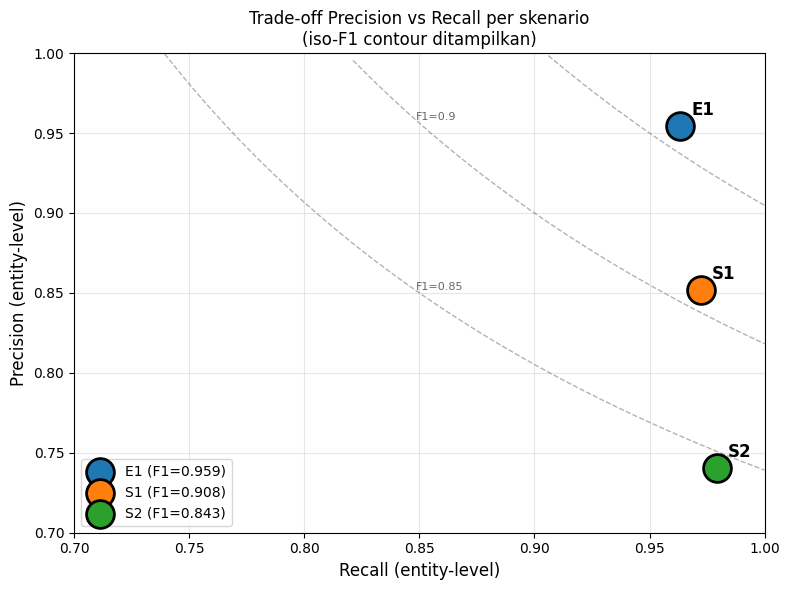

Saved: fig_pr_tradeoff.png


In [13]:
if HAS_SEQEVAL:
    fig, ax = plt.subplots(figsize=(8,6))
    for scen in ['E1','S1','S2']:
        ts, ps = to_seqeval_format(test_dfs[scen])
        p_val = seq_p(ts, ps)
        r_val = seq_r(ts, ps)
        f_val = seq_f1(ts, ps)
        ax.scatter(r_val, p_val, s=400, color=SCENARIO_COLOR[scen], label=f'{scen} (F1={f_val:.3f})',
                   edgecolors='black', linewidth=2, zorder=3)
        ax.annotate(scen, xy=(r_val, p_val), xytext=(8, 8), textcoords='offset points',
                    fontsize=12, fontweight='bold')

    # iso-F1 contour lines
    rs = np.linspace(0.7, 1.0, 100)
    for f in [0.85, 0.90, 0.95]:
        ps_iso = (f * rs) / (2*rs - f)
        ps_iso = np.where((ps_iso > 0) & (ps_iso <= 1.0), ps_iso, np.nan)
        ax.plot(rs, ps_iso, 'k--', alpha=0.3, linewidth=1)
        idx = np.argmin(np.abs(rs - 0.85))
        if not np.isnan(ps_iso[idx]):
            ax.text(rs[idx], ps_iso[idx], f'F1={f}', fontsize=8, alpha=0.6)

    ax.set_xlabel('Recall (entity-level)', fontsize=12)
    ax.set_ylabel('Precision (entity-level)', fontsize=12)
    ax.set_title('Trade-off Precision vs Recall per skenario\n(iso-F1 contour ditampilkan)')
    ax.set_xlim(0.7, 1.0); ax.set_ylim(0.7, 1.0)
    ax.grid(alpha=0.3)
    ax.legend(loc='lower left', fontsize=10)
    plt.tight_layout()
    plt.savefig(f'{ROOT}/fig_pr_tradeoff.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: fig_pr_tradeoff.png')

## 11. Kesimpulan

| Metric | Pemenang |
|--------|----------|
| F1 token-weighted | **E1** (0.9955) — bias karena majority class O |
| F1 macro tanpa O | **S2** (0.8627) — fair untuk unbalanced |
| F1 entity (seqeval) | **E1** (0.9587) — standar NER literatur |
| F1 EVENT (kelas paling minoritas) | **S1** (0.835) — bukti class weight bekerja |
| Recall semua kelas | **S2** — tapi precision drop |
| Best balance | **S1** — F1 entity 0.908, recall ↑, precision masih ok |

**Rekomendasi inference final ke `sirah_chunks_final.csv`: gunakan model S1.**

Detail lengkap analisis di file `analisis_skenario_srlner.md`.